In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import hierarchical Hawkes process library
import hep

# Configure matplotlib
plt.rc('text', usetex=True)
plt.rc('font', family='times')

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
## Simulation settings
T = 100  ## Total time for simulation
jumps = np.array([5, 10, 20, 40, 50, 55, 62, 70, 90, 95])  # External stimuli

# True model parameters (on standard scale, not log-scale)
lambda0_true = 2.0
theta0_alpha_true = 5.0
eta_alpha_true = 3.0
csi_alpha_true = 0.15
theta0_beta_true = 0.25
eta_beta_true = 0.15
csi_beta_true = 0.1
theta0_delta_true = 1.5
# Combine in parameter vector
true_params = np.array([lambda0_true, theta0_alpha_true, eta_alpha_true, csi_alpha_true,
    theta0_beta_true, eta_beta_true, csi_beta_true, theta0_delta_true])

# Apply log-transformation 
true_params_log = np.log(true_params)

init_params1 = [np.log(1.0), np.log(10.0), np.log(7.5), np.log(0.5), np.log(0.5), np.log(0.3), np.log(0.05), np.log(5.0)] 
init_params2 = [np.log(1.0), np.log(10.0), np.log(1.5), np.log(0.1), np.log(0.5), np.log(0.1), np.log(0.15), np.log(0.5)]
init_params3 = [np.log(1.0), np.log(1.0), np.log(5.0), np.log(0.5), np.log(0.75), np.log(0.25), np.log(0.05), np.log(1.0)]

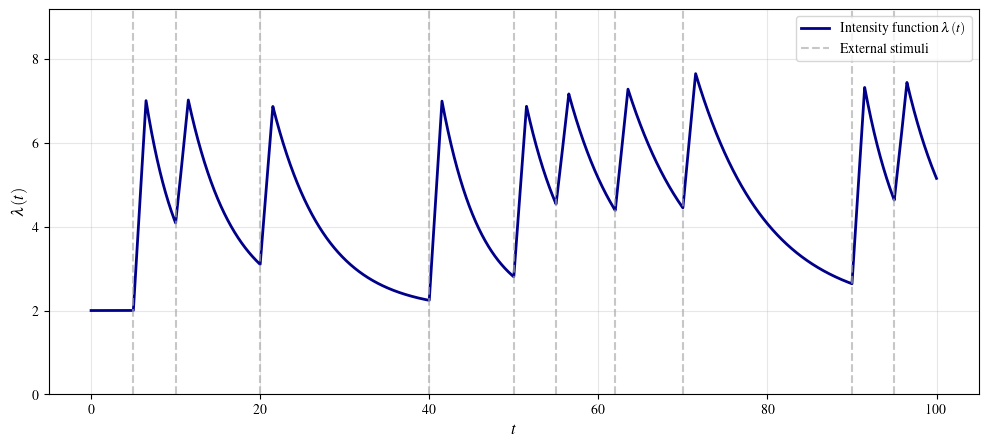

In [3]:
# Visualize the true intensity function
time_grid = np.linspace(0, T, 10000)
true_intensity = hep.calculate_intensity(
    params=true_params_log,
    t=time_grid,
    jumps=jumps,
    add_delay=True,
    fixed_jumps=False,
    fixed_decay=False,
    fixed_delay=True,
    inhibitory_decay=True,
    inhibitory_delay=True,
    log_params=True, 
    right_continuous=False
)

# Plot the true intensity function and the jump locations
plt.figure(figsize=(12, 5))
plt.plot(time_grid, true_intensity, color='darkblue', linewidth=2, label=r'Intensity function $\lambda(t)$')
for jump in jumps:
    plt.axvline(x=jump, color='darkgray', linestyle='--', linewidth=1.5, alpha=0.65, label='External stimuli' if jump == jumps[0] else None)
plt.xlabel(r'$t$', fontsize=12)
plt.ylabel(r'$\lambda(t)$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0, np.max(true_intensity) * 1.2)
plt.legend()
plt.show()

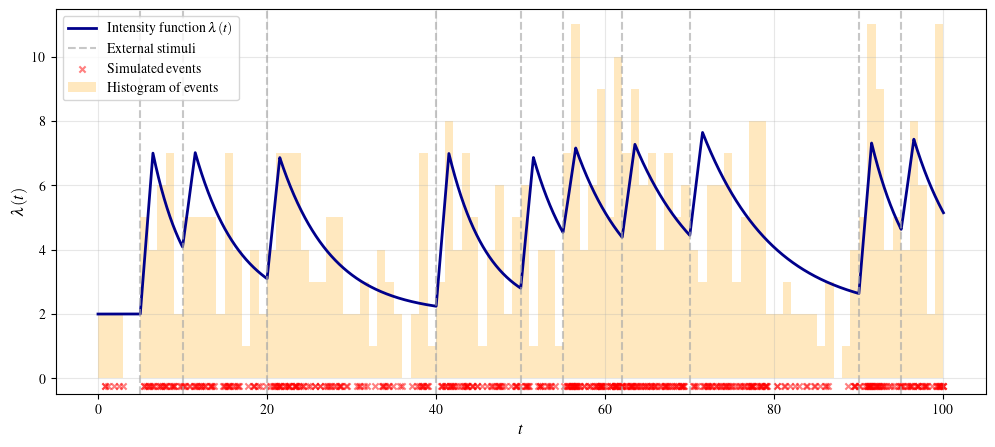

In [ ]:
# Simulate a single dataset to understand the data structure
np.random.seed(117)
events_example = hep.simulate_hep(
    params=true_params_log,
    jumps=jumps,
    T=T,
    add_delay=True,
    fixed_jumps=False,
    fixed_decay=False,
    fixed_delay=True,
    inhibitory_decay=True,
    inhibitory_delay=False,
    log_params=True,
    seed=117
)

# Plot the true intensity function and the jump locations
plt.figure(figsize=(12, 5))
plt.plot(time_grid, true_intensity, color='darkblue', linewidth=2, label=r'Intensity function $\lambda(t)$')
for jump in jumps:
    plt.axvline(x=jump, color='darkgray', linestyle='--', linewidth=1.5, alpha=0.65, label='External stimuli' if jump == jumps[0] else None)
plt.scatter(events_example, np.zeros_like(events_example)-0.25, color='red', s=20, alpha=0.5, label='Simulated events', marker='x')
plt.xlabel(r'$t$', fontsize=12)
plt.ylabel(r'$\lambda(t)$', fontsize=12)
plt.hist(events_example, bins=np.arange(0, T+1), density=False, alpha=0.25, color='orange', label='Histogram of events', 
        edgecolor='none')
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, np.max(true_intensity) * 1.5)
plt.legend()
plt.show()

In [5]:
lambda_max = np.max(hep.calculate_intensity(params=true_params, t=jumps+theta0_delta_true, jumps=jumps,
                                                add_delay=True, fixed_jumps=False,
                                                fixed_decay=False, fixed_delay=True,
                                                inhibitory_decay=True, inhibitory_delay=True,
                                                log_params=False, right_continuous=True))
print(lambda_max)

7.646665947035058


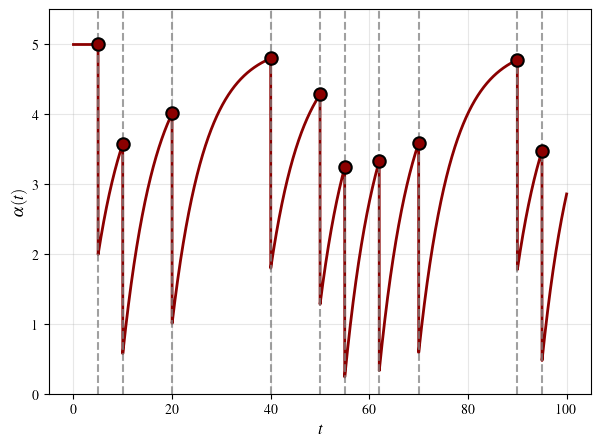

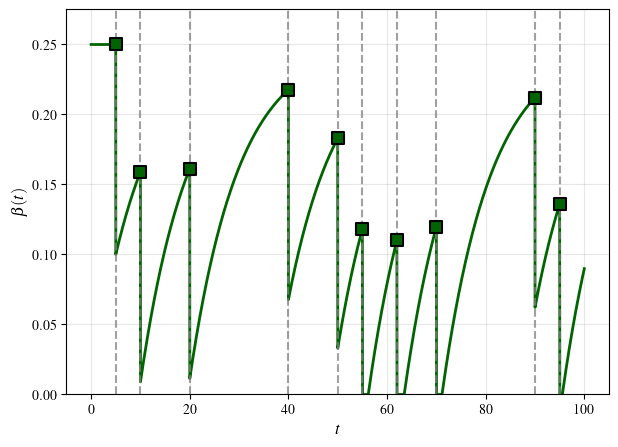

In [6]:
# Visualize the underlying hierarchical parameters alpha(t) and beta(t)
# Extract parameters
theta0_alpha = true_params[1]
eta_alpha = true_params[2]
csi_alpha = true_params[3]
theta0_beta = true_params[4]
eta_beta = true_params[5]
csi_beta = true_params[6]
theta0_delta = true_params[7]

# Calculate alpha(t) and beta(t) for each time point
alphas_t = hep.inhibitory_hawkes_intensity(time_grid, jumps, theta0_alpha, eta_alpha, csi_alpha)
betas_t = hep.inhibitory_hawkes_intensity(time_grid, jumps, theta0_beta, eta_beta, csi_beta)

# Also calculate the values at each jump point
alphas_at_jumps = hep.inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
betas_at_jumps = hep.inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)

# Plot alpha(t)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(time_grid, alphas_t, color='darkred', linewidth=2, label=r'$\alpha(t)$')
ax.scatter(jumps, alphas_at_jumps, color='darkred', s=80, zorder=5, marker='o', 
           edgecolors='black', linewidth=1.5, label=r'$\alpha(\tau_j)$ at jumps')
for jump in jumps:
    ax.axvline(x=jump, color='gray', linestyle='--', linewidth=1.5, alpha=0.75)
ax.set_xlabel(r'$t$', fontsize=12)
ax.set_ylabel(r'$\alpha(t)$', fontsize=12)
ax.set_ylim(0, np.max(alphas_t) * 1.1)
ax.grid(True, alpha=0.3)
plt.show()

# Plot beta(t)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(time_grid, betas_t, color='darkgreen', linewidth=2, label=r'$\beta(t)$')
ax.scatter(jumps, betas_at_jumps, color='darkgreen', s=80, zorder=5, marker='s', 
           edgecolors='black', linewidth=1.5, label=r'$\beta(\tau_j)$ at jumps')
for jump in jumps:
    ax.axvline(x=jump, color='gray', linestyle='--', linewidth=1.5, alpha=0.75)
ax.set_xlabel(r'$t$', fontsize=12)
ax.set_ylabel(r'$\beta(t)$', fontsize=12)
ax.set_ylim(0, np.max(betas_t) * 1.1)
ax.grid(True, alpha=0.3)
plt.show()


In [7]:
# Calculate maximum intensity at jump points
lambda_max = np.max(hep.calculate_intensity(
    params=true_params_log, 
    t=jumps, 
    jumps=jumps,
    add_delay=True, 
    fixed_jumps=False,
    fixed_decay=False, 
    fixed_delay=True,
    inhibitory_decay=True, 
    inhibitory_delay=True,
    log_params=True, 
    right_continuous=True
))

print(lambda_max)


4.63090304390666


Visualise fitted processes against the true process (compare the estimated intensity functions with the true underlying intensity function).

In [ ]:
n_simulations = 1000  # Number of simulations to run

fitted_params = []
nll_values = []

init_params1 = [np.log(10), np.log(10), np.log(7.5), np.log(0.01), np.log(1.0), np.log(0.1), np.log(0.05), np.log(5.0)] 
init_params2 = [np.log(5), np.log(10), np.log(0.5), np.log(0.1), np.log(1.0), np.log(0.1), np.log(0.01), np.log(0.5)]
init_params3 = [np.log(10), np.log(50), np.log(7.5), np.log(0.01), np.log(1.0), np.log(0.1), np.log(0.05), np.log(1.0)]
pvals = {}; mods = {}
for i in range(n_simulations):
    np.random.seed(i+2026)  # Use simulation id as seed for reproducibility
    ## Simulate events
    events = hep.simulate_hep(
            params=true_params_log,
            jumps=jumps,
            T=T,
            add_delay=True,
            fixed_jumps=False,
            fixed_decay=False,
            fixed_delay=True,
            inhibitory_decay=True,
            inhibitory_delay=True,
            log_params=True,
            seed=i+2026
        )
    ## Fit the model with multiple initializations
    pp1 = hep.fit_process(init_params1, events, jumps, T, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=True, fixed_jumps=False, fixed_decay=False, fixed_delay=True, inhibitory_decay=True, inhibitory_delay=True)
    pp2 = hep.fit_process(init_params2, events, jumps, T, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=True, fixed_jumps=False, fixed_decay=False, fixed_delay=True, inhibitory_decay=True, inhibitory_delay=True)
    pp3 = hep.fit_process(init_params3, events, jumps, T, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=True, fixed_jumps=False, fixed_decay=False, fixed_delay=True, inhibitory_decay=True, inhibitory_delay=True)
    ## Choose best fit among three initializations
    fits = [pp1, pp2, pp3]
    fits_ll = [fit.fun for fit in fits]
    best_fit_index = np.argmin(fits_ll)
    pp = fits[best_fit_index]
    ## Store results
    fitted_params.append(pp.x)
    nll_values.append(pp.fun)
    ## Print simulation
    print(f"Simulation {i+1}/{n_simulations}: "
            f"N_events={len(events):<4} NLL={pp.fun:<8.2f} Success", end='\r')

In [10]:
## Save fitted parameters and NLL values for later analysis
fitted_params = np.array(fitted_params)
nll_values = np.array(nll_values)
np.savez('../data/sim1_fitted_params.npz', fitted_params=fitted_params, nll_values=nll_values)

In [8]:
## Import results for analysis
results = np.load('../data/sim1_fitted_params.npz')
fitted_params = results['fitted_params']
nll_values = results['nll_values']

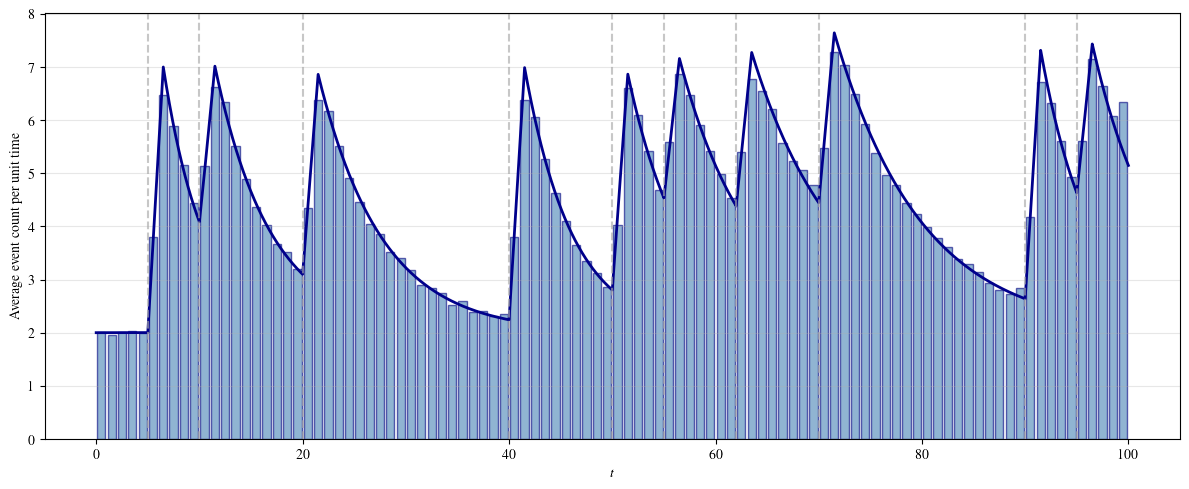

In [ ]:
all_events = {}
n_simulations = 1000
for i in range(n_simulations):
    np.random.seed(2026+i)  # Use simulation id as seed for reproducibility
    ## Simulate events
    all_events[i] = hep.simulate_hep(
            params=true_params_log,
            jumps=jumps,
            T=T,
            add_delay=True,
            fixed_jumps=False,
            fixed_decay=False,
            fixed_delay=True,
            inhibitory_decay=True,
            inhibitory_delay=True,
            log_params=True,
            seed=2026+i
        )

# Create histogram with average count per unit time interval
bin_edges = np.arange(0, T+1, 1)  # 1-unit time intervals
counts_per_simulation = []

for i in range(n_simulations):
    counts, _ = np.histogram(all_events[i], bins=bin_edges)
    counts_per_simulation.append(counts)

# Calculate average counts across all simulations
avg_counts = np.mean(counts_per_simulation, axis=0)

# Plot the histogram
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time_grid, true_intensity, color='darkblue', linewidth=2, label=r'Intensity function $\lambda(t)$')
for jump in jumps:
    ax.axvline(x=jump, color='darkgray', linestyle='--', linewidth=1.5, alpha=0.65, label='External stimuli' if jump == jumps[0] else None)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.bar(bin_centers, avg_counts, width=0.8, alpha=0.6, color='steelblue', edgecolor='navy', linewidth=1)
ax.set_xlabel(r'$t$')
ax.set_ylabel('Average event count per unit time')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


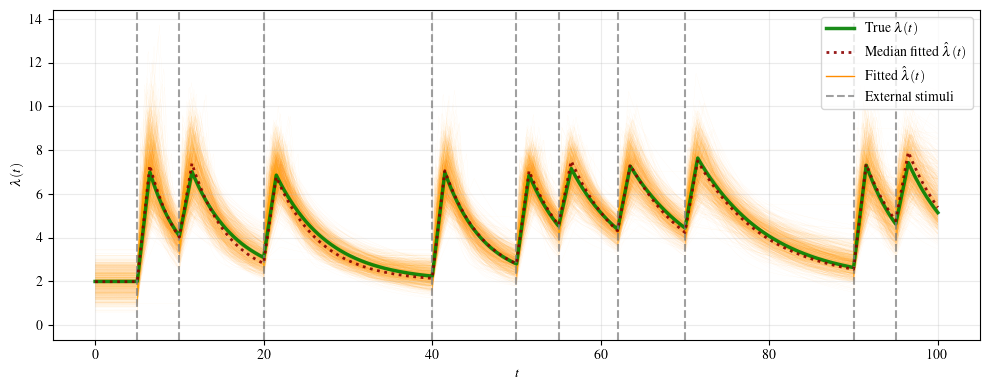

In [10]:
## Calculate fitted intensities for multiple simulations
n_to_plot = len(fitted_params)  # Number of fitted curves in the plot
fitted_intensities_ensemble = []
for i in range(min(n_to_plot, len(fitted_params))):
    intensity = hep.calculate_intensity(
        params=fitted_params[i],
        t=time_grid,
        jumps=jumps,
        add_delay=True,
        fixed_jumps=False,
        fixed_decay=False,
        fixed_delay=True,
        inhibitory_decay=True,
        inhibitory_delay=True,
        log_params=True
    )
    fitted_intensities_ensemble.append(intensity)
## Convert to numpy array
fitted_intensities_ensemble = np.array(fitted_intensities_ensemble)

# Plot ensemble of fitted curves with true curve
fig, ax = plt.subplots(figsize=(10, 4)) 
# Plot true curve
ax.plot(time_grid, true_intensity, color='green', linewidth=2.5, label=r'True $\lambda(t)$', alpha=0.9)
# Plot mean of fitted curves
median_params = np.median(fitted_params, axis=0)
median_intensity = hep.calculate_intensity(
    params=median_params,
    t=time_grid,
    jumps=jumps,
    add_delay=True,
    fixed_jumps=False,
    fixed_decay=False,
    fixed_delay=True,
    inhibitory_decay=True,
    inhibitory_delay=True,
    log_params=True,
    right_continuous=False
)
ax.plot(time_grid, median_intensity, color='darkred', linewidth=2, label=r'Median fitted $\hat{\lambda}(t)$', 
         linestyle='dotted', alpha=0.9, zorder=5)
##ax.plot(time_grid, fitted_intensities_ensemble.mean(axis=0), color='darkorange', linewidth=2, label=r'Mean fitted $\hat{\lambda}(t)$', 
##        linestyle='dashed', alpha=0.9, zorder=5)
# Plot individual fitted curves with transparency
for i in range(len(fitted_intensities_ensemble)):
    ax.plot(time_grid, fitted_intensities_ensemble[i], color='orange', linewidth=0.05, 
            alpha=0.25, label=r'Fitted $\hat{\lambda}(t)$' if i == 0 else None, zorder=1)
# Add changepoints
for jump in jumps:
    ax.axvline(x=jump, color='gray', linestyle='dashed', linewidth=1.5, alpha=0.75, 
               label='External stimuli' if jump == jumps[0] else None)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\lambda(t)$')
## ax.set_xlim(-1, T+1)
## ax.legend(loc='upper right')

from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
# Make the fitted curve legend entry more visible
handles = [Line2D([0], [0], color='darkorange', linewidth=1, alpha=1) if 'Fitted' in label 
           else h for h, label in zip(handles, labels)]
ax.legend(handles=handles, labels=labels, loc='upper right')

ax.grid(True, alpha=0.25)
plt.tight_layout()

plt.savefig('../figures/sim1/intensity_fits_ensemble.pdf', bbox_inches='tight')

plt.show()

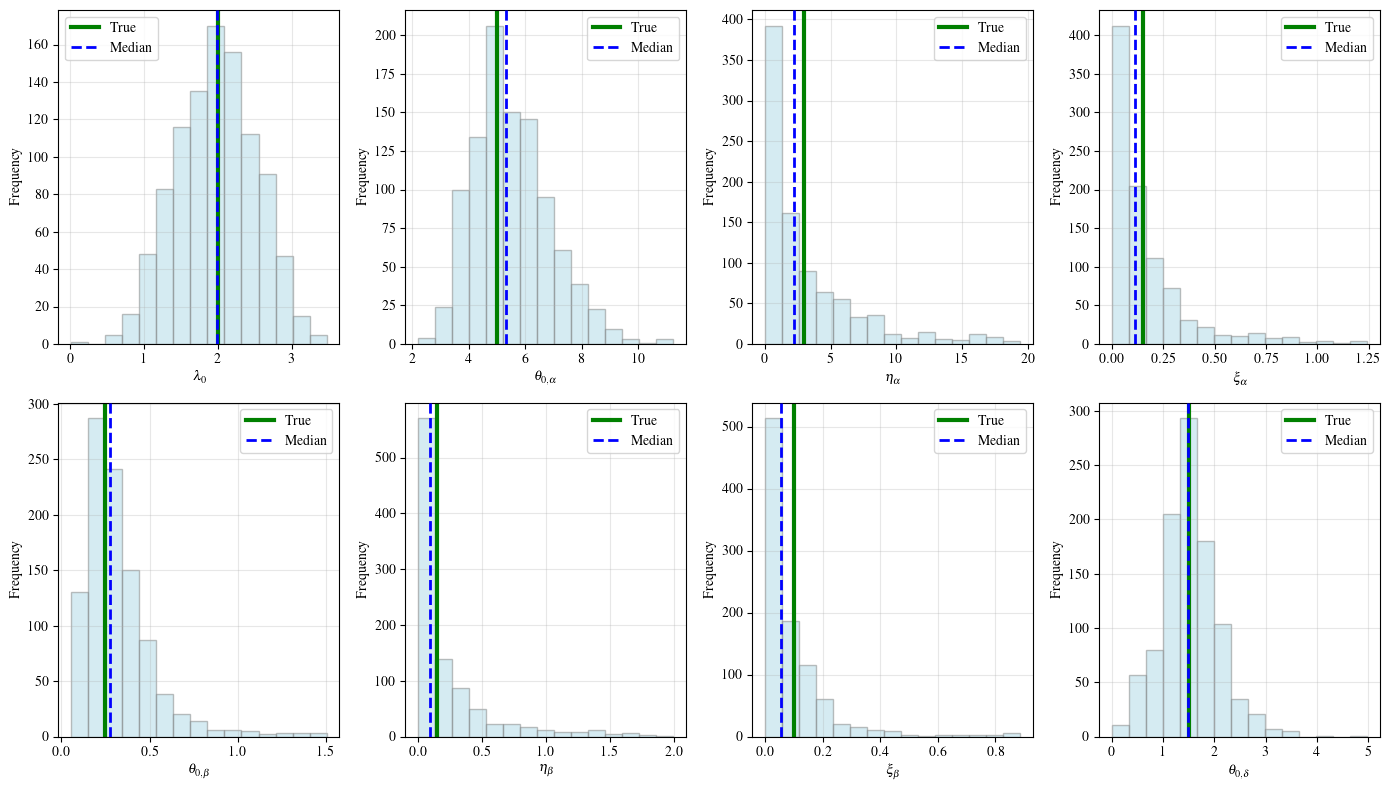

In [11]:
results = np.array(fitted_params)

lims = [100, 100, 20, 1.25, 2, 2, 1, 10]
xlab = [r'$\lambda_0$', r'$\theta_{0,\alpha}$', r'$\eta_\alpha$', r'$\xi_\alpha$',
        r'$\theta_{0,\beta}$', r'$\eta_\beta$', r'$\xi_\beta$', r'$\theta_{0,\delta}$']

# Top plot: first 4 parameters
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for idx in range(8):
    ax = axes.flat[idx]
    fitted_vals = np.exp(results[:,idx])
    
    # Histogram
    subset = fitted_vals[fitted_vals < lims[idx]]
    ax.hist(subset, bins=15, alpha=0.5, color='lightblue', edgecolor='gray', density=False)
    
    # Add vertical lines
    ax.axvline(true_params[idx], color='green', linestyle='-', linewidth=3, label=f"True")
    ax.axvline(np.median(fitted_vals), color='blue', linestyle='--', linewidth=2, label=f"Median", zorder=5)
    
    # Add labels and title
    ax.set_ylabel('Frequency')
    ax.set_xlabel(xlab[idx])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('../figures/sim1/parameter_estimates.pdf', bbox_inches='tight')

plt.show()

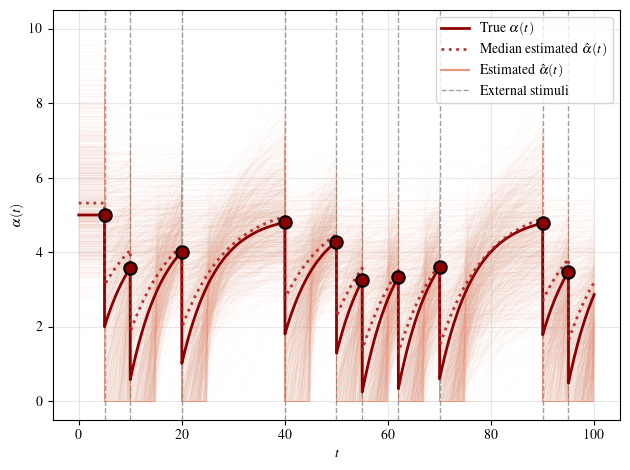

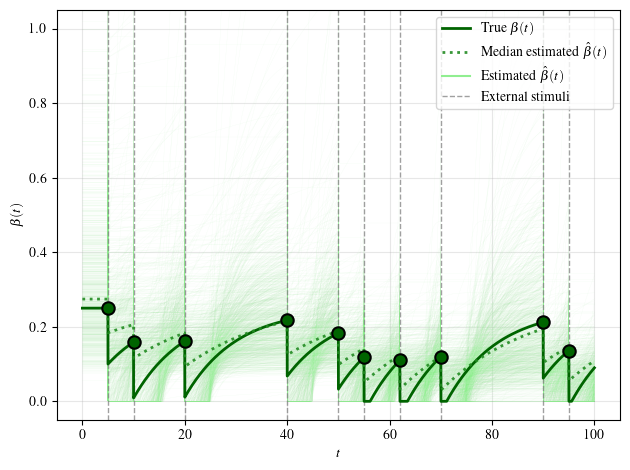

In [12]:
# Visualize the underlying hierarchical parameters alpha(t) and beta(t)
# Extract parameters
theta0_alpha = true_params[1]
eta_alpha = true_params[2]
csi_alpha = true_params[3]
theta0_beta = true_params[4]
eta_beta = true_params[5]
csi_beta = true_params[6]

# Calculate alpha(t) and beta(t) for each time point
alphas_t = hep.inhibitory_hawkes_intensity(time_grid, jumps, theta0_alpha, eta_alpha, csi_alpha)
betas_t = hep.inhibitory_hawkes_intensity(time_grid, jumps, theta0_beta, eta_beta, csi_beta)
alphas_estimated = []
betas_estimated = []
for params in fitted_params:
    params = np.exp(params)  # Convert from log-scale to original scale
    ## Remove extreme values that can cause plotting issues
    if params[1] > 50 or params[4] > 5:
        continue
    else:
        alpha_estimated = hep.inhibitory_hawkes_intensity(time_grid, jumps, params[1], params[2], params[3])
        beta_estimated = hep.inhibitory_hawkes_intensity(time_grid, jumps, params[4], params[5], params[6])
        alphas_estimated.append(alpha_estimated)
        betas_estimated.append(beta_estimated)

# Calculate median of model parameters and construct the corresponding alpha(t) and beta(t)
median_params = np.median(results, axis=0)
median_params_exp = np.exp(median_params)  # Convert from log-scale to original scale
alpha_median = hep.inhibitory_hawkes_intensity(time_grid, jumps, median_params_exp[1], median_params_exp[2], median_params_exp[3])
beta_median = hep.inhibitory_hawkes_intensity(time_grid, jumps, median_params_exp[4], median_params_exp[5], median_params_exp[6])

# Also calculate the values at each jump point
alphas_at_jumps = hep.inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
betas_at_jumps = hep.inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)

plt.plot(time_grid, alphas_t, color='darkred', linewidth=2, label=r'True $\alpha(t)$', zorder=5)
plt.plot(time_grid, alpha_median, color='firebrick', linewidth=2, linestyle='dotted', 
         label=r'Median estimated $\hat{\alpha}(t)$', alpha=0.9, zorder=5)
##plt.plot(time_grid, np.array(alphas_estimated).mean(axis=0), color='orangered', linewidth=2, linestyle='--', 
##         label=r'Median estimated $\hat{\alpha}(t)$', alpha=0.9, zorder=5)
for alpha_estimated in alphas_estimated:
    plt.plot(time_grid, alpha_estimated, color='darksalmon', linewidth=0.15,
            label=r'Estimated $\hat{\alpha}(t)$' if alpha_estimated is alphas_estimated[0] else None, alpha=0.15)
plt.scatter(jumps, alphas_at_jumps, color='darkred', s=80, zorder=5, marker='o', 
           edgecolors='black', linewidth=1.5)
for jump in jumps:
    plt.axvline(x=jump, color='gray', linestyle='--', linewidth=1.0, alpha=0.75, label='External stimuli' if jump == jumps[0] else None)
plt.xlabel(r'$t$')
plt.ylabel(r'$\alpha(t)$')
plt.grid(True, alpha=0.3)
plt.legend()

handles, labels = plt.gca().get_legend_handles_labels()
if len(handles) > 0:
    # Make the fitted curve legend entry more visible
    handles = [Line2D([0], [0], color='darksalmon', linewidth=1.5, alpha=1) if 'Estimated' in label 
               else h for h, label in zip(handles, labels)]
    plt.legend(handles=handles, labels=labels, loc='upper right')
else:
    plt.legend(loc='upper right')
plt.ylim(0-0.5,10+0.5)
plt.tight_layout()
plt.savefig('../figures/sim1/alpha_estimates.pdf', bbox_inches='tight')
plt.show()

# Plot beta(t)
plt.plot(time_grid, betas_t, color='darkgreen', linewidth=2, label=r'True $\beta(t)$', zorder=5)
plt.plot(time_grid, beta_median, color='forestgreen', linewidth=2, linestyle='dotted', 
         label=r'Median estimated $\hat{\beta}(t)$', alpha=0.9, zorder=5)
for beta_estimated in betas_estimated:
    plt.plot(time_grid, beta_estimated, color='lightgreen', linewidth=0.15, 
             label=r'Estimated $\hat{\beta}(t)$' if beta_estimated is betas_estimated[0] else None, alpha=0.15)
plt.scatter(jumps, betas_at_jumps, color='darkgreen', s=80, zorder=5, marker='o', 
           edgecolors='black', linewidth=1.5)
for jump in jumps:
    plt.axvline(x=jump, color='gray', linestyle='--', linewidth=1.0, alpha=0.75, label='External stimuli' if jump == jumps[0] else None)
plt.xlabel(r'$t$')
plt.ylabel(r'$\beta(t)$')
plt.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
handles, labels = plt.gca().get_legend_handles_labels()
if len(handles) > 0:
    # Make the fitted curve legend entry more visible
    handles = [Line2D([0], [0], color='lightgreen', linewidth=1.5, alpha=1) if 'Estimated' in label 
               else h for h, label in zip(handles, labels)]
    plt.legend(handles=handles, labels=labels, loc='upper right')
else:
    plt.legend(loc='upper right')
plt.ylim(0-0.05,1.+0.05)
plt.tight_layout()
plt.savefig('../figures/sim1/beta_estimates.pdf', bbox_inches='tight')
plt.show()

In [29]:
## Filter all_events such that only those less than 60 are kept
n_simulations = 1000
lim = 75
filtered_events = {i: events[events < lim] for i, events in all_events.items()}
fitted_params_restricted = []; nll_values_restricted = []
for i in range(n_simulations):
    np.random.seed(i)  # Use simulation id as seed for reproducibility
    ## Fit the model with multiple initializations
    pp1 = hep.fit_process(init_params1, filtered_events[i], jumps, lim, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=True, fixed_jumps=False, fixed_decay=False, fixed_delay=True, inhibitory_decay=True, inhibitory_delay=True)
    pp2 = hep.fit_process(init_params2, filtered_events[i], jumps, lim, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=True, fixed_jumps=False, fixed_decay=False, fixed_delay=True, inhibitory_decay=True, inhibitory_delay=True)
    pp3 = hep.fit_process(init_params3, filtered_events[i], jumps, lim, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=True, fixed_jumps=False, fixed_decay=False, fixed_delay=True, inhibitory_decay=True, inhibitory_delay=True)
    ## Choose best fit among three initializations
    fits = [pp1, pp2, pp3]
    fits_ll = [fit.fun for fit in fits]
    best_fit_index = np.argmin(fits_ll)
    pp = fits[best_fit_index]
    ## Store results
    fitted_params_restricted.append(pp.x)
    nll_values_restricted.append(pp.fun)
    ## Print simulation
    print(f"Simulation {i+1}/{n_simulations}: "
            f"N_events={len(filtered_events[i]):<4} NLL={pp.fun:<8.2f} Success", end='\r')

In [31]:
## Save fitted parameters and NLL values for later analysis
fitted_params_restricted = np.array(fitted_params_restricted)
nll_values_restricted = np.array(nll_values_restricted)
np.savez('../data/sim1_fitted_params_restricted.npz', fitted_params=fitted_params_restricted, nll_values=nll_values_restricted)

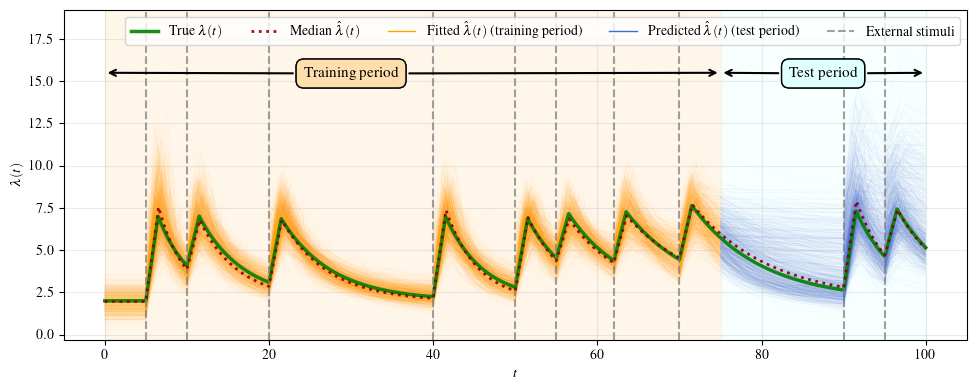

In [37]:
## Calculate fitted intensities for multiple simulations
n_to_plot = len(fitted_params_restricted)  # Number of fitted curves in the plot
fitted_intensities_ensemble = []
for i in range(min(n_to_plot, len(fitted_params_restricted))):
    intensity = hep.calculate_intensity(
        params=fitted_params_restricted[i],
        t=time_grid,
        jumps=jumps,
        add_delay=True,
        fixed_jumps=False,
        fixed_decay=False,
        fixed_delay=True,
        inhibitory_decay=True,
        inhibitory_delay=True,
        log_params=True
    )
    fitted_intensities_ensemble.append(intensity)
## Convert to numpy array
fitted_intensities_ensemble = np.array(fitted_intensities_ensemble)

# Plot ensemble of fitted curves with true curve
fig, ax = plt.subplots(figsize=(10, 4)) 

# Add training and test period shading
ax.axvspan(0, lim, alpha=0.25, color="navajowhite", zorder=0)
ax.axvspan(lim, 100, alpha=0.25, color="lightcyan", zorder=0)

# Plot true curve
ax.plot(time_grid, true_intensity, color='green', linewidth=2.5, label=r'True $\lambda(t)$', alpha=0.9)
# Plot mean of fitted curves
median_params = np.median(fitted_params_restricted, axis=0)
median_intensity = hep.calculate_intensity(
    params=median_params,
    t=time_grid,
    jumps=jumps,
    add_delay=True,
    fixed_jumps=False,
    fixed_decay=False,
    fixed_delay=True,
    inhibitory_decay=True,
    inhibitory_delay=True,
    log_params=True,
    right_continuous=False
)
ax.plot(time_grid, median_intensity, color='darkred', linewidth=2, label=r'Median $\hat{\lambda}(t)$', 
         linestyle='dotted', alpha=0.9, zorder=5)

# Plot individual fitted curves with transparency
for i in range(len(fitted_intensities_ensemble)):
    ax.plot(time_grid[:7500], fitted_intensities_ensemble[i][:7500], color='orange', linewidth=0.05, 
            alpha=0.25, label=r'Fitted $\hat{\lambda}(t)$ (training period)' if i == 0 else None, zorder=1)
    ax.plot(time_grid[7500:], fitted_intensities_ensemble[i][7500:], color='royalblue', linewidth=0.05, 
            alpha=0.25, label=r'Predicted $\hat{\lambda}(t)$ (test period)' if i == 0 else None, zorder=1)
# Add changepoints
for jump in jumps:
    ax.axvline(x=jump, color='gray', linestyle='dashed', linewidth=1.5, alpha=0.75, 
               label='External stimuli' if jump == jumps[0] else None)

# Add text boxes with arrows
ax.annotate('Training period', xy=(lim, 15.5), xytext=(30, 15.25),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=11, ha='center', bbox=dict(boxstyle='round,pad=0.5', facecolor='navajowhite', edgecolor='black', linewidth=1))
ax.annotate('Training period', xy=(0, 15.5), xytext=(30, 15.25),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=11, ha='center', bbox=dict(boxstyle='round,pad=0.5', facecolor='navajowhite', edgecolor='black', linewidth=1))
ax.annotate('Test period', xy=(100, 15.5), xytext=(87.5, 15.25),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=11, ha='center', bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcyan', edgecolor='black', linewidth=1))
ax.annotate('Test period', xy=(lim, 15.5), xytext=(87.5, 15.25),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=11, ha='center', bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcyan', edgecolor='black', linewidth=1))

ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\lambda(t)$')

from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
# Make the fitted curve legend entry more visible
handles = [Line2D([0], [0], color='orange', linewidth=1, alpha=1) if 'training' in label 
           else Line2D([0], [0], color='royalblue', linewidth=1, alpha=1) if 'test' in label else h for h, label in zip(handles, labels)]
ax.legend(handles=handles, labels=labels, loc='upper right', ncol=5)

ax.grid(True, alpha=0.25)
plt.tight_layout()

plt.savefig('../figures/sim1/intensity_fits_ensemble_prediction.pdf', bbox_inches='tight')

plt.show()